In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果系统中安装了 "SimHei" 字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

In [2]:
df = pd.read_csv('../5.1-datablock_analysis/chunk_scores.csv')

各分数段数量：
分数段
0-2        364
2-5        223
5-8        343
8-10       491
10-15     3070
15-20     6750
20-25     7245
25-40     7630
40-100     396
Name: count, dtype: int64

各分数段比例：
分数段
0-2       0.013730
2-5       0.008411
5-8       0.012938
8-10      0.018520
10-15     0.115797
15-20     0.254602
20-25     0.273272
25-40     0.287794
40-100    0.014937
Name: proportion, dtype: float64


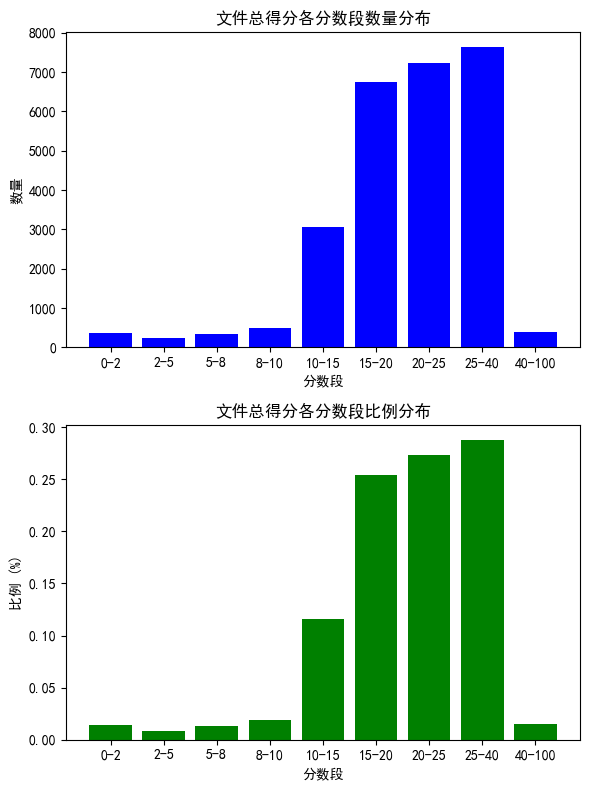

In [3]:
# 统计各个分数段的比例和数量
bins = [0, 2,5,8, 10,15, 20,25, 40,100]
labels = ['0-2', '2-5','5-8', '8-10', '10-15','15-20','20-25','25-40', '40-100']
df['分数段'] = pd.cut(df['score'], bins=bins, labels=labels, right=False)

count_series = df['分数段'].value_counts(sort=False)
percentage_series = df['分数段'].value_counts(normalize=True, sort=False)

# 输出统计信息
print("各分数段数量：")
print(count_series)
print("\n各分数段比例：")
print(percentage_series)

# 绘制柱状图
fig, ax = plt.subplots(2, 1, figsize=(6, 8))

# 数量分布图
ax[0].bar(count_series.index.astype(str), count_series.values, color='blue')
ax[0].set_title('文件总得分各分数段数量分布')
ax[0].set_xlabel('分数段')
ax[0].set_ylabel('数量')

# 比例分布图
ax[1].bar(percentage_series.index.astype(str), percentage_series.values, color='green')
ax[1].set_title('文件总得分各分数段比例分布')
ax[1].set_xlabel('分数段')
ax[1].set_ylabel('比例 (%)')

# 显示图表
plt.tight_layout()
plt.show()

In [4]:
# 筛选出15分数以上的数据
rage0 = 1.0

df_4 = df[(df['score'] >= 40)]
df_4 = df_4.sample(frac=rage0, random_state=42)



# 筛选出10-15分数段的数据，并保留70%

rage1 = 0.9

df_3_4 = df[(df['score'] >= 25) & (df['score'] < 40)]
df_3_4 = df_3_4.sample(frac=rage1, random_state=42)


# 筛选出8-10分数段的数据，并保留60%
rate2 = 0.8

df_2_3 = df[(df['score'] >=20) & (df['score'] < 25)]
df_2_3 = df_2_3.sample(frac=rate2, random_state=42)


# 筛选出5-8分数段的数据，并保留30%
rate3 = 0.5
df_1_2 = df[(df['score'] >= 15) & (df['score'] < 20)]
df_1_2 = df_1_2.sample(frac=rate3, random_state=42)

# 筛选出1-15分数段的数据，并保留30%
rate4 = 0.1
df_0_1 = df[(df['score'] >= 1) & (df['score'] < 15)]
df_0_1 = df_0_1.sample(frac=rate4, random_state=42)


# 合并筛选后的数据
final_df = pd.concat([df_4, df_3_4, df_2_3,df_1_2,df_0_1])

del final_df["分数段"]

final_df["chunk_id"] = [i for i in range(len(final_df))]

columns = ['chunk_id'] + [col for col in final_df.columns if col != 'chunk_id']
final_df = final_df[columns]

# final_df.index.name = 'chunk_id'

# # # 将结果保存到新的CSV文件
# # final_df.to_csv("chunk_scores_result.csv", index=True)
final_df.to_json("./chunk_scores_result.json", orient="records", indent=4, force_ascii=False)


print( len(df), "---->"  ,len(final_df))

26514 ----> 16868
